# SECOM 반도체 불량 예측 및 VM-FDC 가이던스 에이전트

UCI SECOM 센서 데이터를 활용한 불량 사전예측, 비용 최적화, 데이터 증강 기법 통계적 검증, SHAP/LLM 기반 가이던스 에이전트 구현 전체 과정입니다.

## 환경 설정 및 import

In [27]:
# 한글 폰트 설정 (그래프에서 한글이 깨지지 않도록)
import subprocess, sys

try:
    import google.colab  # noqa
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

if IS_COLAB:
    subprocess.run(["apt-get", "-qq", "-y", "install", "fonts-nanum"],
                    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    import matplotlib.font_manager as fm
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    fm.fontManager.addfont(font_path)
    plt_font_name = "NanumGothic"
else:
    # 로컬(Mac/Windows) 환경 - 시스템에 설치된 한글 폰트 사용
    import matplotlib.font_manager as fm
    candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic"]
    available = {f.name for f in fm.fontManager.ttflist}
    plt_font_name = next((c for c in candidates if c in available), None)
    if plt_font_name is None:
        print("⚠️ 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다. "
              "나눔고딕 등을 설치 후 커널을 재시작해주세요.")

import matplotlib.pyplot as plt
if plt_font_name:
    plt.rcParams["font.family"] = plt_font_name
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

In [1]:
# -*- coding: utf-8 -*-
"""
SECOM 반도체 불량 예측 + VM-FDC 가이던스 에이전트
- Cell 1~11 통합본
- 원본: UCI_SECOM_경력_agent반영.ipynb
- 수정사항:
  1) PCA 적용 전 RobustScaler 추가 (GMM+PCA 증강 단계)
  2) Threshold 탐색 범위 확장 (로그스케일 하한 1e-7까지)
  3) fold 내부 상수 컬럼 제거 + selector 적용 함수(apply_selector) 통일
  4) sensor_67 artifact 여부 비교 검증 셀 추가 (Cell 7/7-1/7-2)
  5) 개인 경로/API 키 제거 -> 환경변수/상대경로 사용
  6) Agent 데모에 정상 샘플도 포함 (precision 트레이드오프 투명화)
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import recall_score, precision_score, roc_auc_score
from imblearn.over_sampling import SMOTE
import shap
from openai import OpenAI
import xgboost as xgb

## Cell 1 — 환경 설정

In [2]:
def setup_environment():
    """Colab/로컬 환경을 자동 감지하여 데이터 경로와 API 키를 설정한다."""
    try:
        is_colab = "google.colab" in str(get_ipython())  # noqa: F821
    except NameError:
        is_colab = False

    if is_colab:
        from google.colab import drive, userdata
        drive.mount('/content/drive')
        data_path = "/content/drive/MyDrive/01Wafer/wafer_data/uci-secom.csv"  # 본인 환경 경로
        save_dir = "/content/drive/MyDrive/01Wafer/wafer_data/processed"
        api_key = userdata.get("open_ai_secom")
    else:
        data_path = os.environ.get("SECOM_DATA_PATH", "./data/uci-secom.csv")
        save_dir = "./outputs/processed"
        api_key = os.environ.get("open_ai_secom")

    os.makedirs(save_dir, exist_ok=True)

    client = OpenAI(api_key=api_key) if api_key else None
    if client is None:
        print("ℹ️ OpenAI API 키 없음 — LLM 상세 리포트 비활성화 (SHAP 가이던스는 정상 작동)")

    return data_path, save_dir, client

## Cell 2 — Feature/Label 분리 + 전처리

In [3]:
def load_and_clean_data(data_path):
    df = pd.read_csv(data_path, index_col=0)
    print(df.shape)

    y = df["Pass/Fail"].map({-1: 0, 1: 1})
    X = df.drop(columns=["Pass/Fail"])
    X.columns = [f"sensor_{i}" for i in range(X.shape[1])]

    print("클래스 분포:\n", y.value_counts())
    print(f"불량 비율: {y.mean()*100:.2f}%")

    # 결측치 50% 이상 컬럼 제거
    missing_ratio = X.isna().mean()
    high_missing_cols = missing_ratio[missing_ratio >= 0.5].index.tolist()
    X = X.drop(columns=high_missing_cols)
    print(f"\n[결측치 50%↑ 제거] {len(high_missing_cols)}개 컬럼 제거")

    # 상수 컬럼 제거 (전체 데이터 기준)
    nunique = X.nunique(dropna=True)
    constant_cols = nunique[nunique <= 1].index.tolist()
    X = X.drop(columns=constant_cols)
    print(f"[상수 컬럼 제거] {len(constant_cols)}개 컬럼 제거")

    print(f"\n최종 X shape: {X.shape}")
    return X, y

## Cell 3 — 모델 설정 (XGBoost + Feature Selection)

In [4]:
def get_model(model_name, scale_pos_weight=1.0):
    if model_name == "xgboost":
        return xgb.XGBClassifier(
            objective="binary:logistic", eval_metric="auc",
            scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1,
            n_estimators=200, max_depth=5, learning_rate=0.1,
        )
    raise ValueError(f"지원하지 않는 모델: {model_name}")


def select_top_k_features(X_train_imp, y_train, k=100):
    """
    446개 센서 중 통계적으로 유의한 상위 k개만 선택. train fold 내부에서만 fit (leakage 방지).
    [수정] fold 내부에서 분산이 0이 되는 컬럼을 SelectKBest 적용 전에 제거 (0/0 경고 방지).
    """
    variances = X_train_imp.var(axis=0)
    non_constant_mask = variances > 1e-12

    X_filtered = X_train_imp[:, non_constant_mask]
    selector = SelectKBest(score_func=f_classif, k=min(k, X_filtered.shape[1]))
    X_selected = selector.fit_transform(X_filtered, y_train)

    return X_selected, {"mask": non_constant_mask, "selector": selector}


def apply_selector(X_imp, selector_dict):
    """select_top_k_features와 짝을 이루는 적용 함수. test fold / 신규 샘플에 동일하게 사용."""
    if selector_dict is None:
        return X_imp
    X_filtered = X_imp[:, selector_dict["mask"]]
    return selector_dict["selector"].transform(X_filtered)

## Cell 4 — 증강 함수 (SMOTE / GMM+PCA) [PCA 전 스케일링 추가]

In [5]:
def smote_oversample(X_train, y_train, target_ratio=0.5, random_state=42):
    n_minority = (y_train == 1).sum()
    k_neighbors = min(5, max(n_minority - 1, 1))
    smote = SMOTE(sampling_strategy=target_ratio, k_neighbors=k_neighbors, random_state=random_state)
    return smote.fit_resample(X_train, y_train)


def select_gmm_k_by_bic(X_minority, max_components=4, random_state=42):
    max_components = min(max_components, max(len(X_minority) - 1, 1))
    bic_scores = [
        GaussianMixture(n_components=k, covariance_type="diag",
                         random_state=random_state, reg_covar=1e-3).fit(X_minority).bic(X_minority)
        for k in range(1, max_components + 1)
    ]
    return int(np.argmin(bic_scores) + 1), bic_scores


def gmm_pca_oversample(X_train, y_train, variance_threshold=0.90, max_components=4,
                        target_ratio=0.5, random_state=42):
    """
    [수정] PCA가 측정 단위/분산이 큰 센서에 좌지우지되는 문제를 막기 위해
    PCA 적용 전 RobustScaler로 스케일을 맞춘다.
    1) 스케일링 -> 2) PCA 차원축소 -> 3) 소수 클래스 PCA 투영
    -> 4) BIC로 GMM 컴포넌트 선택 -> 5) 가상 샘플 생성 후 역스케일까지 역변환
    train fold 내부에서만 fit (leakage 방지).
    """
    pre_scaler = RobustScaler()
    X_train_scaled = pre_scaler.fit_transform(X_train)
    X_minority_scaled = X_train_scaled[y_train == 1]

    pca_full = PCA(random_state=random_state).fit(X_train_scaled)
    n_components_pca = int(np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= variance_threshold) + 1)
    pca = PCA(n_components=n_components_pca, random_state=random_state).fit(X_train_scaled)
    X_minority_pca = pca.transform(X_minority_scaled)

    best_k, _ = select_gmm_k_by_bic(X_minority_pca, max_components, random_state)
    gmm = GaussianMixture(n_components=best_k, covariance_type="diag",
                           random_state=random_state, reg_covar=1e-3).fit(X_minority_pca)

    n_majority = (y_train == 0).sum()
    n_minority = (y_train == 1).sum()
    n_to_generate = max(int(n_majority * target_ratio) - n_minority, 0)
    if n_to_generate == 0:
        return X_train, y_train, {"pca_k": n_components_pca, "gmm_k": best_k, "n_generated": 0}

    X_gen_pca, _ = gmm.sample(n_to_generate)
    X_gen_scaled = pca.inverse_transform(X_gen_pca)
    X_gen = pre_scaler.inverse_transform(X_gen_scaled)  # 원래 단위로 복원

    X_aug = np.vstack([X_train, X_gen])
    y_aug = np.concatenate([y_train, np.ones(n_to_generate)])
    return X_aug, y_aug, {"pca_k": n_components_pca, "gmm_k": best_k, "n_generated": n_to_generate}


def gmm_pca_oversample_no_scaling(X_train, y_train, variance_threshold=0.90,
                                    max_components=4, target_ratio=0.5, random_state=42):
    """비교용으로 재현한 '버그 있던' 버전 (스케일링 없이 PCA). Cell 7 검증에서 사용."""
    X_minority = X_train[y_train == 1]
    pca_full = PCA(random_state=random_state).fit(X_train)
    n_components_pca = int(np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= variance_threshold) + 1)
    pca = PCA(n_components=n_components_pca, random_state=random_state).fit(X_train)
    X_minority_pca = pca.transform(X_minority)

    best_k, _ = select_gmm_k_by_bic(X_minority_pca, max_components, random_state)
    gmm = GaussianMixture(n_components=best_k, covariance_type="diag",
                           random_state=random_state, reg_covar=1e-3).fit(X_minority_pca)

    n_majority = (y_train == 0).sum()
    n_to_generate = max(int(n_majority * target_ratio) - len(X_minority), 0)
    if n_to_generate == 0:
        return X_train, y_train
    X_gen_pca, _ = gmm.sample(n_to_generate)
    X_gen = pca.inverse_transform(X_gen_pca)
    X_aug = np.vstack([X_train, X_gen])
    y_aug = np.concatenate([y_train, np.ones(n_to_generate)])
    return X_aug, y_aug

## Cell 5 — Cost-Matrix 기반 최적 Threshold 탐색 [탐색범위 확장]

In [6]:
def find_cost_optimal_threshold(y_proba, y_true, cost_fn=15, cost_fp=1, thresholds=None):
    """
    FN(불량 놓침) 비용이 FP(헛검사)보다 cost_fn배 크다고 가정.
    [수정] cost_ratio가 커지면(100~500) 최적 threshold가 1e-5보다도 작아질 수 있어
    탐색 범위를 로그스케일로 더 낮은 구간까지 확장.
    """
    if thresholds is None:
        thresholds = np.concatenate([
            np.geomspace(1e-7, 1e-3, 60),
            np.linspace(1e-3, 0.01, 30),
            np.linspace(0.01, 0.99, 99),
        ])
        thresholds = np.unique(thresholds)

    results = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tn = ((y_pred == 0) & (y_true == 0)).sum()
        fp = ((y_pred == 1) & (y_true == 0)).sum()
        fn = ((y_pred == 0) & (y_true == 1)).sum()
        tp = ((y_pred == 1) & (y_true == 1)).sum()
        total_cost = fn * cost_fn + fp * cost_fp
        results.append({"threshold": t, "fn": fn, "fp": fp, "tp": tp, "tn": tn, "total_cost": total_cost})

    cost_df = pd.DataFrame(results)
    best_row = cost_df.loc[cost_df["total_cost"].idxmin()]

    if best_row["threshold"] <= thresholds.min() * 1.01:
        min_cost = cost_df["total_cost"].min()
        n_tied = (cost_df["total_cost"] == min_cost).sum()
        print(f"⚠️ 경고: 최적 threshold({best_row['threshold']:.2e})가 탐색 범위 하한 근접. "
              f"동일 비용 threshold {n_tied}개 존재 — cost_ratio={cost_fn}에서는 "
              f"거의 모든 샘플을 검사하는 게 최적이라는 의미일 수 있음.")

    return best_row["threshold"], cost_df

## Cell 6 — VM 비용 민감도 분석 (Unbiased threshold, leakage+양극화 수정본)

In [7]:
def get_unbiased_train_proba(X_train_imp, y_train, augmentation, model_name, cv_splits=3, random_state=42):
    """
    모델은 inner-train(증강 적용)으로 학습하고, inner-val(증강 없음, 원본 클래스 비율)의
    OOF 확률을 모아 threshold 탐색용으로 반환한다.
    -> 증강된 모델을 그대로 train 전체에 적용하면 확률이 양극화되어 cost ratio를 바꿔도
       threshold가 안 움직이는 문제가 생김. inner-val은 원본 분포라 이 문제를 피하고 leakage도 없음.
    """
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    oof_proba = np.zeros(len(y_train))

    for inner_train_idx, inner_val_idx in skf.split(X_train_imp, y_train):
        X_it, X_iv = X_train_imp[inner_train_idx], X_train_imp[inner_val_idx]
        y_it, y_iv = y_train[inner_train_idx], y_train[inner_val_idx]

        if augmentation == "gmm_pca":
            X_fit, y_fit, _ = gmm_pca_oversample(X_it, y_it, random_state=random_state)
        elif augmentation == "smote":
            X_fit, y_fit = smote_oversample(X_it, y_it, random_state=random_state)
        else:
            X_fit, y_fit = X_it, y_it

        spw = (y_fit == 0).sum() / max((y_fit == 1).sum(), 1)
        temp_pipeline = Pipeline([("scaler", RobustScaler()), ("model", get_model(model_name, spw))])
        temp_pipeline.fit(X_fit, y_fit)
        oof_proba[inner_val_idx] = temp_pipeline.predict_proba(X_iv)[:, 1]

    return oof_proba


def quick_vm_cost_simulation(X, y, model_name="xgboost", augmentation="gmm_pca",
                              cost_fn=15, cost_fp=1, outer_splits=5, random_state=42, use_feature_selection=True):
    outer_cv = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=random_state)
    X_arr, y_arr = X.values, y.values

    fold_logs = []
    fold_artifacts = []

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X_arr, y_arr), start=1):
        X_train, X_test = X_arr[train_idx], X_arr[test_idx]
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]

        imputer = SimpleImputer(strategy="median")
        X_train_imp = imputer.fit_transform(X_train)
        X_test_imp = imputer.transform(X_test)

        selector = None
        if use_feature_selection:
            X_train_imp, selector = select_top_k_features(X_train_imp, y_train, k=100)
            X_test_imp = apply_selector(X_test_imp, selector)

        if augmentation == "gmm_pca":
            X_fit, y_fit, _ = gmm_pca_oversample(X_train_imp, y_train, random_state=random_state)
        elif augmentation == "smote":
            X_fit, y_fit = smote_oversample(X_train_imp, y_train, random_state=random_state)
        else:
            X_fit, y_fit = X_train_imp, y_train

        spw = (y_fit == 0).sum() / max((y_fit == 1).sum(), 1)
        pipeline = Pipeline([("scaler", RobustScaler()), ("model", get_model(model_name, spw))])
        pipeline.fit(X_fit, y_fit)

        train_proba_unbiased = get_unbiased_train_proba(
            X_train_imp, y_train, augmentation, model_name, random_state=random_state
        )
        best_thr, _ = find_cost_optimal_threshold(train_proba_unbiased, y_train, cost_fn, cost_fp)

        y_proba = pipeline.predict_proba(X_test_imp)[:, 1]
        y_pred = (y_proba >= best_thr).astype(int)
        n_total = len(y_test)
        n_flagged = y_pred.sum()
        inspection_reduction = 1 - (n_flagged / n_total)

        fold_logs.append({
            "fold": fold_idx, "best_threshold": best_thr,
            "n_total": n_total, "n_flagged": n_flagged,
            "inspection_reduction_pct": inspection_reduction * 100,
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "auc": roc_auc_score(y_test, y_proba),
        })

        fold_artifacts.append({
            "fold": fold_idx, "pipeline": pipeline, "imputer": imputer, "selector": selector,
            "test_idx": test_idx, "train_idx": train_idx, "best_threshold": best_thr,
        })

        print(f"[Fold {fold_idx}] thr={best_thr:.4f} 검사량감소={inspection_reduction*100:.1f}% "
              f"Recall={fold_logs[-1]['recall']:.3f} Precision={fold_logs[-1]['precision']:.3f} "
              f"AUC={fold_logs[-1]['auc']:.3f}")

    return pd.DataFrame(fold_logs), fold_artifacts

## Cell 6-1 — VM 비용 민감도 분석 (Cost Ratio 스윕)

In [8]:
def vm_cost_sensitivity_analysis(fold_artifacts, X, y, augmentation="gmm_pca", model_name="xgboost",
                                   cost_ratios=(5, 7, 10, 13, 15, 20, 25, 30, 40, 50, 100, 200, 500)):
    fold_data = []
    for art in fold_artifacts:
        X_train_imp = art["imputer"].transform(X.values[art["train_idx"]])
        X_test_imp = art["imputer"].transform(X.values[art["test_idx"]])
        X_train_imp = apply_selector(X_train_imp, art["selector"])
        X_test_imp = apply_selector(X_test_imp, art["selector"])

        y_train = y.values[art["train_idx"]]
        y_test = y.values[art["test_idx"]]

        train_proba_unbiased = get_unbiased_train_proba(
            X_train_imp, y_train, augmentation, model_name, random_state=42
        )
        test_proba = art["pipeline"].predict_proba(X_test_imp)[:, 1]
        fold_data.append((train_proba_unbiased, y_train, test_proba, y_test))

    sensitivity_results = []
    for ratio in cost_ratios:
        fold_metrics = []
        for train_proba_unbiased, y_train, test_proba, y_test in fold_data:
            best_thr, _ = find_cost_optimal_threshold(train_proba_unbiased, y_train, cost_fn=ratio, cost_fp=1)
            y_pred = (test_proba >= best_thr).astype(int)
            fold_metrics.append({
                "recall": recall_score(y_test, y_pred, zero_division=0),
                "precision": precision_score(y_test, y_pred, zero_division=0),
                "inspection_reduction_pct": (1 - y_pred.mean()) * 100,
            })
        avg_metrics = pd.DataFrame(fold_metrics).mean()
        sensitivity_results.append({"cost_ratio": ratio, **avg_metrics.to_dict()})
        print(f"[Cost Ratio {ratio:4d}:1] Recall={avg_metrics['recall']:.3f} "
              f"검사량감소={avg_metrics['inspection_reduction_pct']:.1f}%")

    return pd.DataFrame(sensitivity_results)


def plot_cost_sensitivity(sensitivity_df):
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(sensitivity_df["cost_ratio"], sensitivity_df["recall"], marker="o", color="tab:blue", label="Recall")
    ax1.set_xlabel("Cost Ratio (FN cost : FP cost)")
    ax1.set_ylabel("Recall", color="tab:blue")
    ax1.set_xscale("log")
    ax2 = ax1.twinx()
    ax2.plot(sensitivity_df["cost_ratio"], sensitivity_df["inspection_reduction_pct"],
              marker="s", color="tab:orange", label="Inspection Reduction (%)")
    ax2.set_ylabel("Inspection Reduction (%)", color="tab:orange")
    plt.title("VM Screening Trade-off: Recall vs Inspection Reduction by Cost Ratio")
    fig.tight_layout()
    plt.show()

## Cell 7 — Feature Importance 비교 검증 (PCA 스케일링 수정 전/후)

In [9]:
def get_importance(X, X_imp_full, y_full, augment_fn):
    if augment_fn is gmm_pca_oversample:
        X_aug, y_aug, _ = augment_fn(X_imp_full, y_full, random_state=42)
    elif augment_fn is gmm_pca_oversample_no_scaling:
        X_aug, y_aug = augment_fn(X_imp_full, y_full, random_state=42)
    else:
        X_aug, y_aug = X_imp_full, y_full

    spw = (y_aug == 0).sum() / max((y_aug == 1).sum(), 1)
    pipeline = Pipeline([("scaler", RobustScaler()), ("model", get_model("xgboost", spw))])
    pipeline.fit(X_aug, y_aug)
    return pd.DataFrame({
        "sensor": X.columns,
        "importance": pipeline.named_steps["model"].feature_importances_
    }).sort_values("importance", ascending=False)


def run_importance_comparison(X, y):
    imputer_full = SimpleImputer(strategy="median")
    X_imp_full = imputer_full.fit_transform(X)

    print("=== (1) 스케일링 없는 GMM+PCA 증강 (기존 버그 버전, 비교용) ===")
    importance_no_scaling = get_importance(X, X_imp_full, y.values, gmm_pca_oversample_no_scaling)
    print(importance_no_scaling.head(10))

    print("\n=== (2) 스케일링 적용한 GMM+PCA 증강 (수정 버전) ===")
    importance_scaled = get_importance(X, X_imp_full, y.values, gmm_pca_oversample)
    print(importance_scaled.head(10))

    print("\n=== (3) 증강 없음 (기준선) ===")
    importance_none = get_importance(X, X_imp_full, y.values, None)
    print(importance_none.head(10))

    return importance_no_scaling, importance_scaled, importance_none

## Cell 7-1 — sensor_67 순위 비교 및 artifact 판정

In [10]:
def get_rank(importance_df, sensor_name):
    df_reset = importance_df.reset_index(drop=True)
    matched = df_reset.query(f'sensor=="{sensor_name}"').index
    return matched[0] + 1 if len(matched) > 0 else None


def judge_artifact_sensor(importance_no_scaling, importance_scaled, importance_none,
                           sensor_name="sensor_67"):
    rank_bug = get_rank(importance_no_scaling, sensor_name)
    rank_fixed = get_rank(importance_scaled, sensor_name)
    rank_none = get_rank(importance_none, sensor_name)

    comparison = pd.DataFrame({
        "sensor": [sensor_name],
        "rank_no_scaling (버그)": [rank_bug],
        "rank_scaled (수정)": [rank_fixed],
        "rank_none (기준선)": [rank_none],
    })
    print(f"=== {sensor_name} 순위 비교 ===")
    print(comparison.to_string(index=False))

    is_artifact = bool(rank_bug and rank_bug <= 5 and (rank_fixed is None or rank_fixed > 20))

    if is_artifact:
        print(f"\n✅ 판정: {sensor_name}은 PCA 스케일링 누락으로 인한 artifact였음 (수정 후 순위 급락 확인)")
        known_artifact_sensors = {sensor_name}
    elif rank_fixed and rank_fixed <= 10:
        print(f"\n⚠️ 판정: 스케일링 수정 후에도 {sensor_name}이 여전히 상위 -> 다른 원인 의심, 추가 조사 필요")
        known_artifact_sensors = set()
    else:
        print(f"\nℹ️ 판정 불확실 -> importance_no_scaling/importance_scaled 직접 비교 검토 필요")
        known_artifact_sensors = set()

    trusted_sensors = importance_scaled.head(10)["sensor"].tolist()
    print(f"\nKNOWN_ARTIFACT_SENSORS = {known_artifact_sensors}")
    print(f"TRUSTED_SENSORS = {trusted_sensors}")

    return known_artifact_sensors, trusted_sensors

## Cell 7-2 — 세 버전 Top 10 시각화 비교

In [11]:
def plot_importance_comparison(importance_no_scaling, importance_scaled, importance_none,
                                 highlight_sensor="sensor_67"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    versions = [
        ("스케일링 없음 (버그)", importance_no_scaling),
        ("스케일링 적용 (수정)", importance_scaled),
        ("증강 없음 (기준선)", importance_none),
    ]

    for ax, (title, df) in zip(axes, versions):
        top10 = df.head(10)
        colors = ["crimson" if s == highlight_sensor else "steelblue" for s in top10["sensor"]]
        ax.barh(top10["sensor"][::-1], top10["importance"][::-1], color=colors[::-1])
        ax.set_title(title)
        ax.set_xlabel("Importance")

    plt.suptitle(f"PCA 스케일링 수정 전/후 Feature Importance 비교 (빨강 = {highlight_sensor})", fontsize=13)
    plt.tight_layout()
    plt.show()

## Cell 8 — SHAP 설명 추출 함수

In [12]:
def get_shap_explanation(sample_idx_in_array, feature_names, shap_values, sample_values, top_n=5):
    shap_row = shap_values[sample_idx_in_array]
    top_idx = np.argsort(np.abs(shap_row))[::-1][:top_n]
    return [
        {"sensor": feature_names[i], "value": float(sample_values[sample_idx_in_array][i]),
         "shap_contribution": float(shap_row[i])}
        for i in top_idx
    ]

## Cell 9 — EtchProcessAgent 클래스

In [13]:
class EtchProcessAgent:
    """
    VM-FDC 가이던스 에이전트
    - Stage 1: 비용 민감형 동적 스크리닝 (Decision-Making)
    - Stage 2: Artifact 필터링 기반 원인 진단 (XAI Guidance)
    - Stage 3: 가상 피드백 제어 (Action Control, mocking)
    """
    def __init__(self, pipeline, imputer, selector, threshold: float, cost_ratio: float,
                 artifact_features: list, trusted_sensors: list, high_risk_proba: float = 0.7,
                 llm_client=None):
        self.pipeline = pipeline
        self.imputer = imputer
        self.selector = selector
        self.threshold = threshold
        self.cost_ratio = cost_ratio
        self.artifact_features = set(artifact_features)
        self.trusted_sensors = trusted_sensors
        self.high_risk_proba = high_risk_proba
        self.llm_client = llm_client

    def _predict_proba(self, wafer_fdc_data: np.ndarray) -> float:
        X_imp = self.imputer.transform(wafer_fdc_data)
        X_imp = apply_selector(X_imp, self.selector)
        return self.pipeline.predict_proba(X_imp)[0, 1]

    def monitor_wafer(self, wafer_fdc_data: np.ndarray, feature_names: list, wafer_id: str = "unknown") -> dict:
        fail_prob = self._predict_proba(wafer_fdc_data)

        if fail_prob >= self.threshold:
            print(f"[⚠️ 위험 감지] Wafer {wafer_id} 불량 확률: {fail_prob:.4f} "
                  f"(기준 {self.threshold:.4f}, Cost Ratio {self.cost_ratio}:1) -> 정밀 VM 대상 선별")
            shap_explanation = self._get_shap_explanation(wafer_fdc_data, feature_names)
            guidance = self._generate_guidance(fail_prob, shap_explanation, wafer_id)
            action = self._decide_action(fail_prob, guidance["top_sensor"])
            self._execute_action(action)
            return {"wafer_id": wafer_id, "fail_prob": fail_prob, "routing": "INSPECT",
                    "top_sensor": guidance["top_sensor"], "action_type": action["action_type"]}
        else:
            print(f"[✅ 정상 공정] Wafer {wafer_id} 불량 확률: {fail_prob:.4f} -> 다음 공정 Pass (검사 비용 절감)")
            return {"wafer_id": wafer_id, "fail_prob": fail_prob, "routing": "PASS",
                    "top_sensor": None, "action_type": "MONITOR_ONLY"}

    def _get_shap_explanation(self, wafer_fdc_data: np.ndarray, feature_names: list, top_n: int = 5) -> list:
        X_imp = self.imputer.transform(wafer_fdc_data)
        X_imp = apply_selector(X_imp, self.selector)
        explainer = shap.TreeExplainer(self.pipeline.named_steps["model"])
        shap_row = explainer.shap_values(X_imp)[0]
        top_idx = np.argsort(np.abs(shap_row))[::-1][:top_n]
        return [
            {"sensor": feature_names[i], "value": float(X_imp[0][i]), "shap_contribution": float(shap_row[i])}
            for i in top_idx
        ]

    def _filter_trusted(self, shap_explanation: list) -> list:
        filtered = [
            item for item in shap_explanation
            if item["sensor"] not in self.artifact_features and item["sensor"] in self.trusted_sensors
        ]
        if not filtered:
            filtered = [item for item in shap_explanation if item["sensor"] not in self.artifact_features]
        return filtered[:3]

    def _get_top_risk_increasing_sensor(self, trusted: list) -> tuple:
        risk_increasing = [item for item in trusted if item["shap_contribution"] > 0]
        if risk_increasing:
            top = max(risk_increasing, key=lambda x: x["shap_contribution"])
            return top["sensor"], True
        if trusted:
            return trusted[0]["sensor"], False
        return "unknown", False

    def _generate_guidance(self, fail_prob: float, shap_explanation: list, wafer_id: str) -> dict:
        excluded = [item["sensor"] for item in shap_explanation if item["sensor"] in self.artifact_features]
        trusted = self._filter_trusted(shap_explanation)
        top_sensor, is_risk_increasing = self._get_top_risk_increasing_sensor(trusted)

        print(f"[🤖 Agent 가이던스 리포트] Wafer {wafer_id}")
        if excluded:
            print(f" - 제외된 Artifact 센서: {', '.join(excluded)} (GMM+PCA 증강 산물로 판정)")
        print(f" - 주요 유발 인자(위험 증가 기준): {top_sensor}"
              f"{'' if is_risk_increasing else ' (※ 위험 증가 센서 없어 영향력 1위로 대체)'}")
        print(f" - 추천 액션: {top_sensor} 관련 Recipe 파라미터 및 Chamber 상태 점검")

        if self.llm_client is not None:
            report_text = self._generate_llm_report(fail_prob, trusted, excluded, wafer_id, top_sensor, is_risk_increasing)
            print(f"\n[LLM 상세 리포트]\n{report_text}")

        return {"top_sensor": top_sensor}

    def _generate_llm_report(self, fail_prob: float, trusted_shap: list, excluded: list,
                               wafer_id: str, top_sensor: str, is_risk_increasing: bool) -> str:
        context = f"샘플 ID: {wafer_id}\n불량 확률: {fail_prob:.1%} (기준 {self.threshold:.4f})\n\n"
        if excluded:
            context += f"[필터링됨] 증강 Artifact로 판명되어 제외된 센서: {', '.join(excluded)}\n\n"
        context += "신뢰 검증된 주요 인자 (SHAP 기여도 순):\n"
        for item in trusted_shap:
            direction = "위험 증가" if item["shap_contribution"] > 0 else "위험 감소"
            context += f"- {item['sensor']}: 측정값 {item['value']:.2f}, {direction} (기여도 {item['shap_contribution']:.3f})\n"

        context += f"\n점검 대상으로 지정된 센서: {top_sensor}"
        if is_risk_increasing:
            context += " (위험 증가 방향 기여 센서 중 우선순위 1위)"
        else:
            context += " (이번 샘플에는 위험 증가 방향 센서가 없어, 영향력이 가장 큰 센서를 대신 지정함 — 해석에 주의 필요)"

        prompt = f"""당신은 반도체 Etch 공정 엔지니어를 보조하는 진단 어시스턴트입니다.
아래 정보는 머신러닝 모델 분석 결과이며, 신뢰할 수 없는 증강 artifact 센서는 이미 제외되었습니다.
점검 대상 센서가 '위험 증가 방향'으로 선정된 것인지, 아니면 '위험 증가 센서가 없어 대체된 것'인지
context에 명시되어 있으니 이를 정확히 반영해서 설명하세요. 점검 대상 센서가 위험을 감소시키는
방향이라면, 그 사실을 숨기지 말고 솔직하게 언급하세요. 제공된 정보 외의 내용을 추정하거나 단정하지 마세요.

{context}

형식:
1. 종합 판단 (1줄)
2. 핵심 원인 추정 센서 및 해석 (2~3줄, 점검 대상 센서가 위험 증가/감소 중 어느 방향인지 명확히 언급)
3. 권고 조치 (1~2줄)
"""
        response = self.llm_client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.2,
        )
        return response.choices[0].message.content

    def _decide_action(self, fail_prob: float, top_sensor: str) -> dict:
        if fail_prob >= self.high_risk_proba:
            return {
                "action_type": "INTERLOCK",
                "signal": "EQUIPMENT_PAUSE_REQUEST",
                "message": f"불량 확률 {fail_prob:.1%} - 고위험. 장비 일시 정지 시그널 발신(모킹). "
                           f"엔지니어 확인 전까지 후속 웨이퍼 투입 보류 권장.",
            }
        elif fail_prob >= self.threshold:
            return {
                "action_type": "RECIPE_ADJUSTMENT_SUGGESTION",
                "signal": "RECIPE_REVIEW_REQUEST",
                "message": f"불량 확률 {fail_prob:.1%} - 중위험. {top_sensor} 관련 Recipe 파라미터 점검 권장 "
                           f"(예: 해당 공정 Step의 가스 유량/RF Power ±5% 조정 검토).",
            }
        return {"action_type": "MONITOR_ONLY", "signal": "NONE", "message": "정상 범위 - 추가 조치 불필요."}

    def _execute_action(self, action: dict) -> None:
        print(f"[🔧 Interlock/Recipe 시스템 모킹] action_type={action['action_type']}, signal={action['signal']}")
        print(f"  -> {action['message']}")

## Cell 10 — Agent 인스턴스 생성 + Held-out 데모 (불량+정상 함께 시연)

In [14]:
def run_agent_demo(X, y, fold_artifacts, vm_results, known_artifact_sensors, trusted_sensors, client,
                    fold_id_for_demo=0, cost_fn=15, cost_fp=1, high_risk_proba=0.7):
    demo_fold = fold_artifacts[fold_id_for_demo]
    assert demo_fold["fold"] == fold_id_for_demo + 1

    pipeline_demo = demo_fold["pipeline"]
    imputer_demo = demo_fold["imputer"]
    selector_demo = demo_fold["selector"]
    test_idx = demo_fold["test_idx"]
    train_idx = demo_fold["train_idx"]

    X_train_demo_imp = imputer_demo.transform(X.values[train_idx])
    X_train_demo_imp = apply_selector(X_train_demo_imp, selector_demo)

    train_proba_unbiased_demo = get_unbiased_train_proba(
        X_train_demo_imp, y.values[train_idx], augmentation="gmm_pca", model_name="xgboost", random_state=42
    )
    optimal_threshold_demo, _ = find_cost_optimal_threshold(
        train_proba_unbiased_demo, y.values[train_idx], cost_fn=cost_fn, cost_fp=cost_fp
    )
    print(f"적용 threshold: {optimal_threshold_demo:.4f} (Cost Ratio {cost_fn}:1, unbiased)")

    fold1_thr_from_cell6 = vm_results.loc[vm_results["fold"] == demo_fold["fold"], "best_threshold"].values[0]
    print(f"[검증] Cell 6 threshold: {fold1_thr_from_cell6:.4f} vs Cell 10 threshold: {optimal_threshold_demo:.4f} "
          f"{'✅ 일치' if abs(fold1_thr_from_cell6 - optimal_threshold_demo) < 0.001 else '⚠️ 불일치'}")

    agent = EtchProcessAgent(
        pipeline=pipeline_demo, imputer=imputer_demo, selector=selector_demo,
        threshold=optimal_threshold_demo, cost_ratio=cost_fn,
        artifact_features=list(known_artifact_sensors), trusted_sensors=trusted_sensors,
        high_risk_proba=high_risk_proba,
        llm_client=client,
    )

    # 불량 샘플 전체 + 정상 샘플 일부를 함께 시연 (precision 트레이드오프 투명화)
    fail_idx_in_test = np.where(y.values[test_idx] == 1)[0]
    pass_idx_sample = np.random.RandomState(42).choice(
        np.where(y.values[test_idx] == 0)[0], size=min(10, (y.values[test_idx] == 0).sum()), replace=False
    )
    demo_idx = np.concatenate([fail_idx_in_test, pass_idx_sample])

    correct, false_positives = 0, 0
    results_log = []

    for i in demo_idx:
        wafer_id = str(X.index[test_idx][i])
        true_label = y.values[test_idx][i]
        wafer_data = X.values[test_idx][i:i+1]
        result = agent.monitor_wafer(wafer_data, feature_names=list(X.columns), wafer_id=wafer_id)
        result["true_label"] = "Fail" if true_label == 1 else "Pass"
        results_log.append(result)

        if true_label == 1:
            correct += (result["routing"] == "INSPECT")
        else:
            false_positives += (result["routing"] == "INSPECT")
        print()

    n_fail = len(fail_idx_in_test)
    n_pass_sampled = len(pass_idx_sample)
    print(f"=== 불량 샘플 감지: {correct}/{n_fail}건 (Recall={correct/n_fail:.1%}) ===")
    print(f"=== 정상 샘플 중 오탐(헛검사): {false_positives}/{n_pass_sampled}건 "
          f"(이 모델의 precision 특성상 일부 오탐은 의도된 trade-off) ===")

    return results_log, agent

## Cell 11 — 결과 저장

In [15]:
def save_results(results_log, save_dir):
    results_summary_df = pd.DataFrame(results_log)
    out_path = f"{save_dir}/etch_agent_demo_results.csv"
    results_summary_df.to_csv(out_path, index=False)
    print(results_summary_df)
    print(f"\n결과 저장 완료: {out_path}")
    return results_summary_df

## Cell 12 — Repeated Nested CV (5x5): None vs SMOTE vs GMM+PCA 비교

In [16]:
def repeated_nested_cv_comparison(X, y, augmentations=("none", "smote", "gmm_pca"),
                                    n_repeats=5, n_outer_splits=5, model_name="xgboost",
                                    cost_fn=15, cost_fp=1, use_feature_selection=True, k=100):
    """
    각 증강 방법에 대해 n_repeats x n_outer_splits 번 평가를 반복하여
    fold당 점수 25개(5x5)를 확보한다. -> Wilcoxon test에 쓸 표본 크기 확보.

    [중요] Feature Selection은 항상 GMM+PCA보다 먼저 적용 (440차원 -> 100차원).
    """
    X_arr, y_arr = X.values, y.values
    all_results = []

    for repeat_idx in range(n_repeats):
        seed = 100 + repeat_idx
        outer_cv = StratifiedKFold(n_splits=n_outer_splits, shuffle=True, random_state=seed)

        for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X_arr, y_arr), start=1):
            X_train, X_test = X_arr[train_idx], X_arr[test_idx]
            y_train, y_test = y_arr[train_idx], y_arr[test_idx]

            imputer = SimpleImputer(strategy="median")
            X_train_imp = imputer.fit_transform(X_train)
            X_test_imp = imputer.transform(X_test)

            selector = None
            if use_feature_selection:
                X_train_imp, selector = select_top_k_features(X_train_imp, y_train, k=k)
                X_test_imp = apply_selector(X_test_imp, selector)

            for aug in augmentations:
                if aug == "gmm_pca":
                    X_fit, y_fit, _ = gmm_pca_oversample(X_train_imp, y_train, random_state=seed)
                elif aug == "smote":
                    X_fit, y_fit = smote_oversample(X_train_imp, y_train, random_state=seed)
                else:
                    X_fit, y_fit = X_train_imp, y_train

                spw = (y_fit == 0).sum() / max((y_fit == 1).sum(), 1)
                pipeline = Pipeline([("scaler", RobustScaler()), ("model", get_model(model_name, spw))])
                pipeline.fit(X_fit, y_fit)

                train_proba_unbiased = get_unbiased_train_proba(
                    X_train_imp, y_train, aug, model_name, random_state=seed
                )
                best_thr, _ = find_cost_optimal_threshold(train_proba_unbiased, y_train, cost_fn, cost_fp)

                y_proba = pipeline.predict_proba(X_test_imp)[:, 1]
                y_pred = (y_proba >= best_thr).astype(int)

                all_results.append({
                    "repeat": repeat_idx + 1, "fold": fold_idx, "augmentation": aug,
                    "recall": recall_score(y_test, y_pred, zero_division=0),
                    "precision": precision_score(y_test, y_pred, zero_division=0),
                    "auc": roc_auc_score(y_test, y_proba),
                    "inspection_reduction_pct": (1 - y_pred.mean()) * 100,
                })

            print(f"[Repeat {repeat_idx+1}/{n_repeats}, Fold {fold_idx}/{n_outer_splits}] 완료 "
                  f"({len(augmentations)}개 증강방법 평가)")

    return pd.DataFrame(all_results)

## Cell 13 — 증강 방법별 평균/표준편차 요약

In [17]:
def summarize_repeated_results(repeated_results):
    summary = repeated_results.groupby("augmentation")[
        ["recall", "precision", "auc", "inspection_reduction_pct"]
    ].agg(["mean", "std"])
    print("=== 증강 방법별 성능 요약 (25회 반복 기준) ===")
    print(summary.round(4))

    print("\n=== 한눈에 보기 ===")
    for aug in repeated_results["augmentation"].unique():
        sub = repeated_results[repeated_results["augmentation"] == aug]
        print(f"\n[{aug}]")
        print(f"  Recall:    {sub['recall'].mean():.3f} ± {sub['recall'].std():.3f}")
        print(f"  Precision: {sub['precision'].mean():.3f} ± {sub['precision'].std():.3f}")
        print(f"  AUC:       {sub['auc'].mean():.3f} ± {sub['auc'].std():.3f}")
        print(f"  검사량감소: {sub['inspection_reduction_pct'].mean():.1f}% ± {sub['inspection_reduction_pct'].std():.1f}%")
    return summary

## Cell 14 — Wilcoxon Signed-Rank Test

In [18]:
def run_wilcoxon_comparisons(repeated_results, metric="auc"):
    """
    Wilcoxon signed-rank test는 '짝지어진(paired)' 비교라서,
    같은 repeat+fold에서 나온 점수끼리 비교한다.
    """
    from scipy.stats import wilcoxon
    from itertools import combinations

    augmentations = repeated_results["augmentation"].unique()
    results = []

    pivot = repeated_results.pivot_table(index=["repeat", "fold"], columns="augmentation", values=metric)

    print(f"=== Wilcoxon Signed-Rank Test 결과 (지표: {metric}) ===")
    print(f"(짝지어진 표본 수: {len(pivot)}개)\n")

    for aug_a, aug_b in combinations(augmentations, 2):
        scores_a = pivot[aug_a].values
        scores_b = pivot[aug_b].values

        stat, p_value = wilcoxon(scores_a, scores_b)
        mean_diff = scores_a.mean() - scores_b.mean()
        better = aug_a if mean_diff > 0 else aug_b

        sig = "✅ 유의함 (p<0.05)" if p_value < 0.05 else "❌ 유의하지 않음"
        print(f"[{aug_a} vs {aug_b}] 평균차이={mean_diff:+.4f} ({aug_a}={scores_a.mean():.4f}, {aug_b}={scores_b.mean():.4f})")
        print(f"  Wilcoxon p-value = {p_value:.4f} -> {sig}")
        if p_value < 0.05:
            print(f"  -> '{better}'가 통계적으로 더 우수함")
        print()

        results.append({
            "metric": metric, "comparison": f"{aug_a} vs {aug_b}",
            "mean_diff": mean_diff, "p_value": p_value,
            "significant": p_value < 0.05, "better": better if p_value < 0.05 else "N/A",
        })

    return pd.DataFrame(results)


def run_all_wilcoxon_tests(repeated_results, save_dir):
    wilcoxon_auc = run_wilcoxon_comparisons(repeated_results, metric="auc")
    wilcoxon_recall = run_wilcoxon_comparisons(repeated_results, metric="recall")
    wilcoxon_precision = run_wilcoxon_comparisons(repeated_results, metric="precision")

    all_wilcoxon = pd.concat([wilcoxon_auc, wilcoxon_recall, wilcoxon_precision], ignore_index=True)
    all_wilcoxon.to_csv(f"{save_dir}/wilcoxon_test_results.csv", index=False)
    print("=== 전체 검정 결과 요약 ===")
    print(all_wilcoxon[["metric", "comparison", "mean_diff", "p_value", "significant", "better"]])
    return all_wilcoxon

## Cell 15 — 결과 시각화 (Boxplot)

In [19]:
def plot_augmentation_comparison(repeated_results):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    metrics = ["recall", "precision", "auc"]
    titles = ["Recall (25 runs)", "Precision (25 runs)", "AUC (25 runs)"]

    for ax, metric, title in zip(axes, metrics, titles):
        data_by_aug = [repeated_results[repeated_results["augmentation"] == aug][metric].values
                       for aug in ["none", "smote", "gmm_pca"]]
        ax.boxplot(data_by_aug, labels=["None", "SMOTE", "GMM+PCA"])
        ax.set_title(title)
        ax.set_ylabel(metric.capitalize())
        ax.grid(axis="y", alpha=0.3)

    plt.suptitle("Augmentation Method Comparison: 5x5 Repeated Nested CV (25 runs each)", fontsize=13)
    plt.tight_layout()
    plt.show()


# =============================================================================
# 메인 실행 흐름
# =============================================================================

## 실행: 데이터 준비

In [20]:
# 실행 — 환경설정 및 데이터 로드
data_path, save_dir, client = setup_environment()
X, y = load_and_clean_data(data_path)

Mounted at /content/drive
(1567, 591)
클래스 분포:
 Pass/Fail
0    1463
1     104
Name: count, dtype: int64
불량 비율: 6.64%

[결측치 50%↑ 제거] 28개 컬럼 제거
[상수 컬럼 제거] 116개 컬럼 제거

최종 X shape: (1567, 446)


## 실행: VM 비용 시뮬레이션

In [21]:
# 실행 — VM 비용 시뮬레이션 (5-fold)
vm_results, fold_artifacts = quick_vm_cost_simulation(
    X, y, model_name="xgboost", augmentation="gmm_pca", cost_fn=15, cost_fp=1, use_feature_selection=True
)
print("\n=== VM 스크리닝 시뮬레이션 평균 ===")
print(vm_results[["inspection_reduction_pct", "recall", "precision", "auc"]].mean())

[Fold 1] thr=0.0097 검사량감소=72.6% Recall=0.524 Precision=0.128 AUC=0.711
[Fold 2] thr=0.0038 검사량감소=52.5% Recall=0.714 Precision=0.101 AUC=0.728
[Fold 3] thr=0.0044 검사량감소=63.3% Recall=0.650 Precision=0.113 AUC=0.716
[Fold 4] thr=0.0081 검사량감소=70.0% Recall=0.571 Precision=0.128 AUC=0.711
[Fold 5] thr=0.0057 검사량감소=65.2% Recall=0.571 Precision=0.110 AUC=0.656

=== VM 스크리닝 시뮬레이션 평균 ===
inspection_reduction_pct    64.712358
recall                       0.606190
precision                    0.115875
auc                          0.704585
dtype: float64


## 실행: Cost Ratio 민감도 분석

[Cost Ratio    5:1] Recall=0.201 검사량감소=93.4%
[Cost Ratio    7:1] Recall=0.279 검사량감소=88.8%
[Cost Ratio   10:1] Recall=0.423 검사량감소=80.5%
[Cost Ratio   13:1] Recall=0.566 검사량감소=67.7%
[Cost Ratio   15:1] Recall=0.606 검사량감소=64.7%
[Cost Ratio   20:1] Recall=0.723 검사량감소=54.8%
[Cost Ratio   25:1] Recall=0.837 검사량감소=44.3%
[Cost Ratio   30:1] Recall=0.885 검사량감소=31.0%
[Cost Ratio   40:1] Recall=0.933 검사량감소=22.1%
[Cost Ratio   50:1] Recall=0.952 검사량감소=12.6%
[Cost Ratio  100:1] Recall=0.981 검사량감소=8.5%
[Cost Ratio  200:1] Recall=0.981 검사량감소=8.5%
[Cost Ratio  500:1] Recall=0.981 검사량감소=8.5%


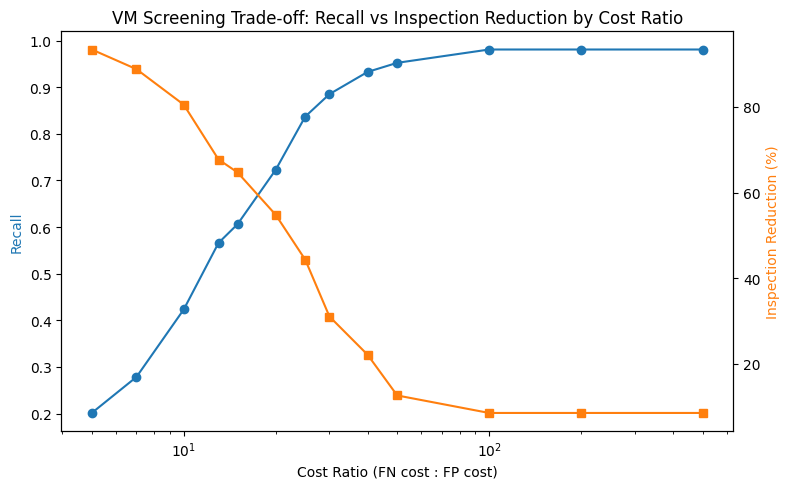

In [23]:
# 실행 — Cost Ratio 민감도 분석
sensitivity_df = vm_cost_sensitivity_analysis(fold_artifacts, X, y)
plot_cost_sensitivity(sensitivity_df)

## 실행: Feature Importance & Artifact 검증

=== (1) 스케일링 없는 GMM+PCA 증강 (기존 버그 버전, 비교용) ===
         sensor  importance
62    sensor_67    0.220073
127  sensor_140    0.027146
392  sensor_521    0.020969
23    sensor_25    0.011815
217  sensor_272    0.008813
6      sensor_7    0.008374
341  sensor_441    0.008264
362  sensor_472    0.007409
27    sensor_29    0.007083
178  sensor_204    0.006801

=== (2) 스케일링 적용한 GMM+PCA 증강 (수정 버전) ===
         sensor  importance
66    sensor_74    0.360077
101  sensor_114    0.060154
220  sensor_275    0.028007
4      sensor_4    0.013735
399  sensor_539    0.009617
177  sensor_203    0.008253
431  sensor_571    0.006998
393  sensor_522    0.006916
62    sensor_67    0.006778
434  sensor_574    0.005789

=== (3) 증강 없음 (기준선) ===
         sensor  importance
44    sensor_47    0.020941
292  sensor_365    0.020514
352  sensor_455    0.019409
50    sensor_55    0.016509
54    sensor_59    0.015029
117  sensor_130    0.014402
175  sensor_201    0.014223
378  sensor_489    0.013493
230  sensor_287    

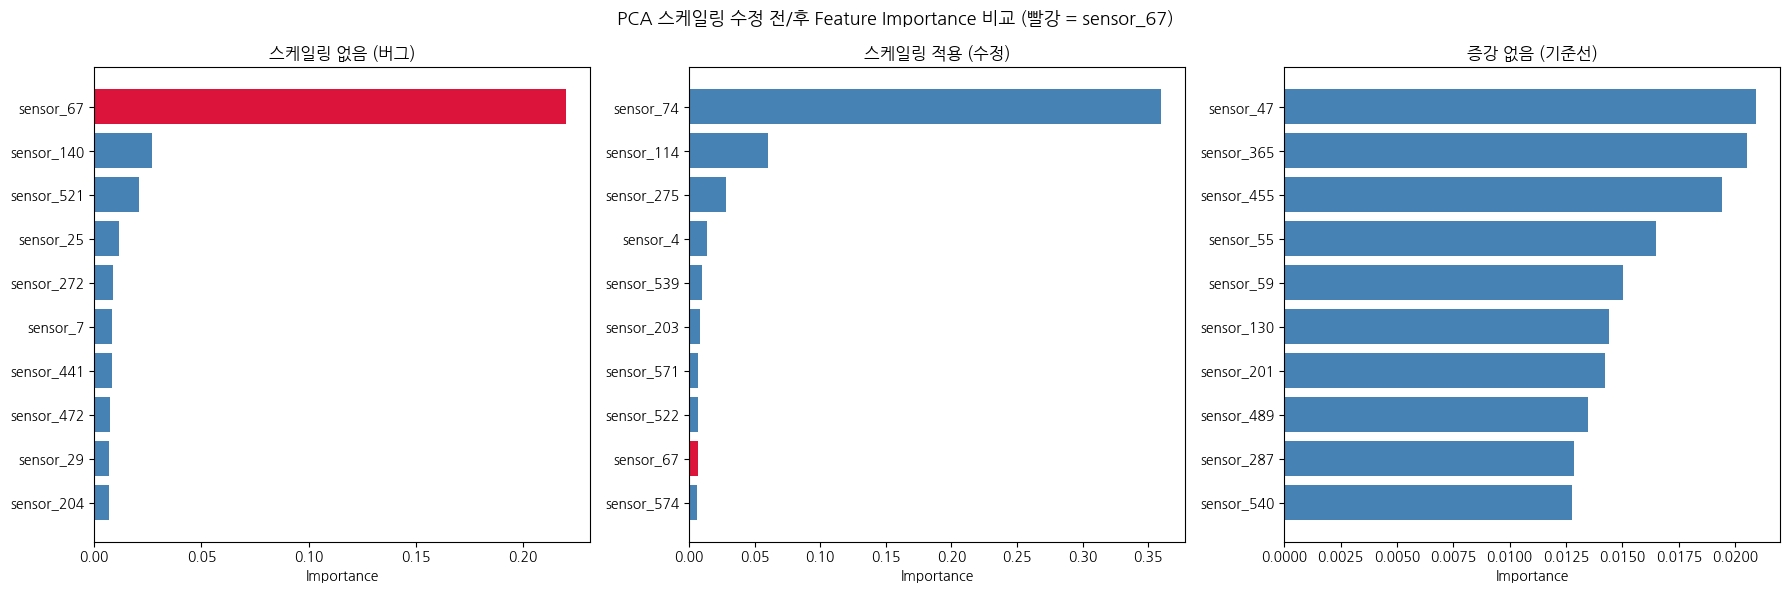

In [28]:
# 실행 — Feature Importance 비교 및 Artifact 판정
importance_no_scaling, importance_scaled, importance_none = run_importance_comparison(X, y)
known_artifact_sensors, trusted_sensors = judge_artifact_sensor(
    importance_no_scaling, importance_scaled, importance_none, sensor_name="sensor_67"
)
plot_importance_comparison(importance_no_scaling, importance_scaled, importance_none)

## 실행: VM-FDC Agent 데모

In [25]:
# 실행 — Agent 데모
results_log, agent = run_agent_demo(
    X, y, fold_artifacts, vm_results, known_artifact_sensors, trusted_sensors, client,
    fold_id_for_demo=0, cost_fn=15, cost_fp=1, high_risk_proba=0.7
)
save_results(results_log, save_dir)

적용 threshold: 0.0097 (Cost Ratio 15:1, unbiased)
[검증] Cell 6 threshold: 0.0097 vs Cell 10 threshold: 0.0097 ✅ 일치
[✅ 정상 공정] Wafer 2008-07-29 08:23:00 불량 확률: 0.0035 -> 다음 공정 Pass (검사 비용 절감)

[✅ 정상 공정] Wafer 2008-07-29 15:49:00 불량 확률: 0.0016 -> 다음 공정 Pass (검사 비용 절감)

[✅ 정상 공정] Wafer 2008-07-29 18:08:00 불량 확률: 0.0049 -> 다음 공정 Pass (검사 비용 절감)

[✅ 정상 공정] Wafer 2008-01-08 05:52:00 불량 확률: 0.0025 -> 다음 공정 Pass (검사 비용 절감)

[⚠️ 위험 감지] Wafer 2008-06-08 05:40:00 불량 확률: 0.0315 (기준 0.0097, Cost Ratio 15:1) -> 정밀 VM 대상 선별
[🤖 Agent 가이던스 리포트] Wafer 2008-06-08 05:40:00
 - 주요 유발 인자(위험 증가 기준): sensor_15
 - 추천 액션: sensor_15 관련 Recipe 파라미터 및 Chamber 상태 점검

[LLM 상세 리포트]
1. 종합 판단: 점검 대상 센서인 sensor_15는 위험 증가 방향으로 기여하고 있습니다.

2. 핵심 원인 추정 센서 및 해석: sensor_15는 측정값이 6.66으로, 위험 증가에 기여하는 주요 센서로 선정되었습니다. 반면, sensor_24는 위험을 감소시키는 방향으로 기여하고 있으며, 그 기여도는 -1.042입니다.

3. 권고 조치: sensor_15의 상태를 면밀히 점검하고, 필요시 조치를 취하여 위험을 최소화하는 것이 필요합니다.
[🔧 Interlock/Recipe 시스템 모킹] action_type=RECIPE_ADJUSTMENT_SUGGESTION, signal=RECIPE_REVIEW_R

,wafer_id,fail_prob,routing,top_sensor,action_type,true_label
0,2008-07-29 08:23:00,0.003480,PASS,None,MONITOR_ONLY,Fail
1,2008-07-29 15:49:00,0.001595,PASS,None,MONITOR_ONLY,Fail
2,2008-07-29 18:08:00,0.004888,PASS,None,MONITOR_ONLY,Fail
3,2008-01-08 05:52:00,0.002512,PASS,None,MONITOR_ONLY,Fail
4,2008-06-08 05:40:00,0.031514,INSPECT,sensor_15,RECIPE_ADJUSTMENT_SUGGESTION,Fail
5,2008-07-08 11:40:00,0.002975,PASS,None,MONITOR_ONLY,Fail
6,2008-09-08 09:16:00,0.516945,INSPECT,sensor_15,RECIPE_ADJUSTMENT_SUGGESTION,Fail
7,2008-10-08 07:01:00,0.115390,INSPECT,sensor_15,RECIPE_ADJUSTMENT_SUGGESTION,Fail
8,2008-08-17 22:03:00,0.041995,INSPECT,sensor_15,RECIPE_ADJUSTMENT_SUGGESTION,Fail
9,2008-08-18 17:13:00,0.005124,PASS,None,MONITOR_ONLY,Fail


## 실행: 증강 기법 통계적 비교 (5×5 Repeated Nested CV + Wilcoxon Test)

[Repeat 1/5, Fold 1/5] 완료 (3개 증강방법 평가)
[Repeat 1/5, Fold 2/5] 완료 (3개 증강방법 평가)
[Repeat 1/5, Fold 3/5] 완료 (3개 증강방법 평가)
[Repeat 1/5, Fold 4/5] 완료 (3개 증강방법 평가)
[Repeat 1/5, Fold 5/5] 완료 (3개 증강방법 평가)
[Repeat 2/5, Fold 1/5] 완료 (3개 증강방법 평가)
[Repeat 2/5, Fold 2/5] 완료 (3개 증강방법 평가)
[Repeat 2/5, Fold 3/5] 완료 (3개 증강방법 평가)
[Repeat 2/5, Fold 4/5] 완료 (3개 증강방법 평가)
[Repeat 2/5, Fold 5/5] 완료 (3개 증강방법 평가)
[Repeat 3/5, Fold 1/5] 완료 (3개 증강방법 평가)
[Repeat 3/5, Fold 2/5] 완료 (3개 증강방법 평가)
[Repeat 3/5, Fold 3/5] 완료 (3개 증강방법 평가)
[Repeat 3/5, Fold 4/5] 완료 (3개 증강방법 평가)
[Repeat 3/5, Fold 5/5] 완료 (3개 증강방법 평가)
[Repeat 4/5, Fold 1/5] 완료 (3개 증강방법 평가)
[Repeat 4/5, Fold 2/5] 완료 (3개 증강방법 평가)
[Repeat 4/5, Fold 3/5] 완료 (3개 증강방법 평가)
[Repeat 4/5, Fold 4/5] 완료 (3개 증강방법 평가)
[Repeat 4/5, Fold 5/5] 완료 (3개 증강방법 평가)
[Repeat 5/5, Fold 1/5] 완료 (3개 증강방법 평가)
[Repeat 5/5, Fold 2/5] 완료 (3개 증강방법 평가)
[Repeat 5/5, Fold 3/5] 완료 (3개 증강방법 평가)
[Repeat 5/5, Fold 4/5] 완료 (3개 증강방법 평가)
[Repeat 5/5, Fold 5/5] 완료 (3개 증강방법 평가)
=== 증강 방법별 성능 요약 (25회 반복 

/tmp/ipykernel_6078/4181615412.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_aug, labels=["None", "SMOTE", "GMM+PCA"])
/tmp/ipykernel_6078/4181615412.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_aug, labels=["None", "SMOTE", "GMM+PCA"])
/tmp/ipykernel_6078/4181615412.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_aug, labels=["None", "SMOTE", "GMM+PCA"])


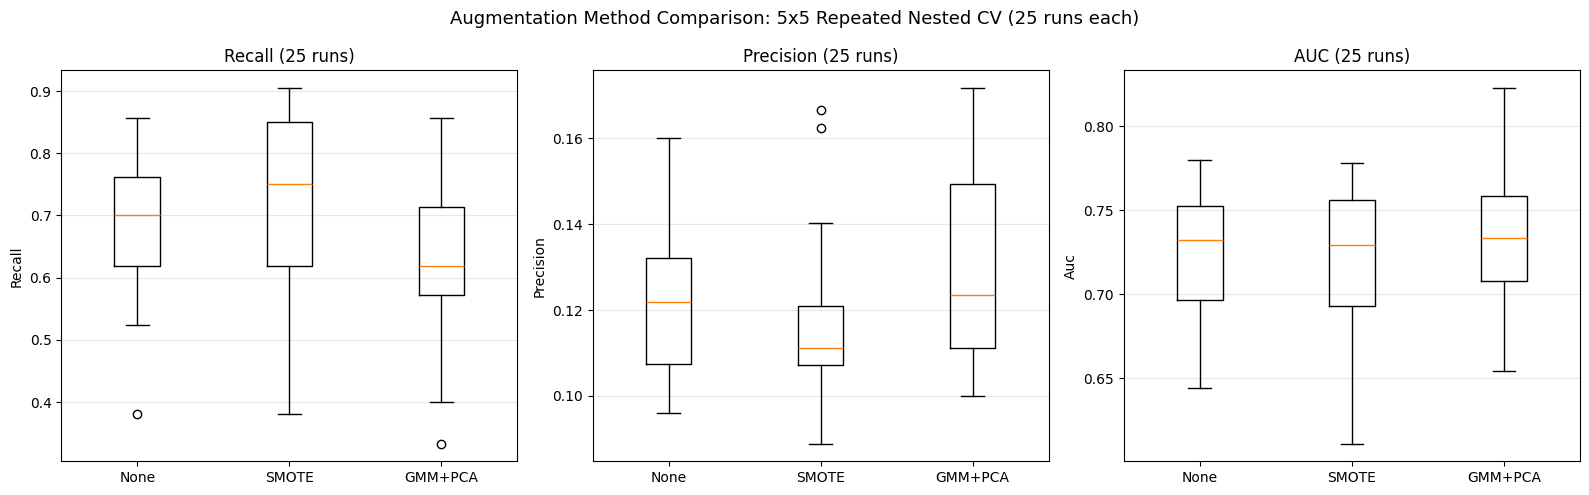

In [26]:
# 실행 — 5x5 Repeated Nested CV + Wilcoxon Test (통계적 검증)
repeated_results = repeated_nested_cv_comparison(
    X, y, augmentations=("none", "smote", "gmm_pca"),
    n_repeats=5, n_outer_splits=5, cost_fn=15, cost_fp=1, use_feature_selection=True
)
repeated_results.to_csv(f"{save_dir}/repeated_nested_cv_results.csv", index=False)

summarize_repeated_results(repeated_results)
run_all_wilcoxon_tests(repeated_results, save_dir)
plot_augmentation_comparison(repeated_results)